## Part 3: Measuring Performance

How do we actually measure the accuracy of facial recognition systems? We have two metrics of interest: accuracy and error. These are relatively simple mathematical concepts, and you may have heard of them before. Here are their formulas:
$$
\text{Accuracy} = \frac{\text{\# correct results}}{\text{\# total results}}
$$
$$
\text{Error} = \frac{\text{\# wrong results}}{\text{\# total results}}
$$

Let's begin with a simple example. Dowload \link{}{this dataset} which contains a facial recognition model's prediction of a subject's sex, across 86,744 subjects. Each Line in the file represents a prediction, with the last column denoting whether the model was correct (`1`) or incorrect (`0`). There is more to explore how accuracy/ error differ for different racial groups and sexes, but for now we'll just calculate the overall error. 

First, let's import some basic libraries that will allow us to read in data for evaluation and display it nicely:

    `pandas`      - Python library for efficiently organizing, analyzing, and manipulating structured data using dataframes and series
    `matplotlib`  - Python library for creating static, animated, and interactive visualizations such as plots, charts, and graphs.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

Now, before we perform our calculations, let's get a better sense of the data we're working with.

We're pulling data from a *CSV* file called `evaluation_dataset.csv`. "*CSV*" stands for "comma separated value", which if you take a peek in the file, you'll see, as each line of text has several values listed, separated by commas. Think of this file format like a spreadsheet. Each line of text is a row, and the commas delineate the columns. 

For `evaluation_dataset.csv` in particular, we're dealing with 86,744 rows, each of which contains metadata about how some facial recognition model classified some image of a person. Each image has been assigned 7 attributes (7 columns), which are:
* `file`: the filename of the image that was processed
* `age`: The age of the person in the image
* `gender`: The sex of the person in the image
* `race`: The race of the person in the image
* `true_label`: Again, the sex of the person in the image
* `predicted_label`: What the model deduced the subject's sex to be
* `correct`: A boolean; It's value is `1` if the model was correct, `0` if not.

Now that we know what we're dealing with, let's calculate the error and accuracy metrics in the facial recognition model's evaluations:

In [13]:
# Read the CSV evaluation dataset
df = pd.read_csv('datasets/evaluation_dataset.csv')

# Get the final column (assuming it's the last one)
results = df.iloc[:, -1]

# Calculate total number of predictions
total = len(results)

# Calculate number of correct predictions (1s)
correct = results.sum()

# Calculate accuracy
accuracy = correct / total

# Calcualte number of wrong predictions (0s)
wrong = total - correct

# Calculate error - (Notice that error is simply 1 - accuracy!)

error = wrong / total

# Print out our results!
print(f"Accuracy: {accuracy:.4f}")
print(f"Error: {error:.4f}")

Accuracy: 0.8004
Error: 0.1996


It's that simple! And notice the relationship between Accuracy and Error: they sum up to 1!

## Part 4: Measuring Bias Using Accuracy/Error

Now that we understand how to compute accuracy and error for a computer vision model, we can use these metrics to investigate potential demographic biases. In particular, we’ll examine the model’s error rate across different racial groups to determine whether it performs worse on some groups than others. Consistently higher error for a specific group may indicate a bias in the model, often stemming from imbalances or gaps in the training data.

We’ll start by writing code to calculate the error rate for each racial group. Then, we’ll use matplotlib to visualize these results, making any disparities easier to interpret.

In [14]:
# Group by race and calculate error for each group
grouped = df.groupby('race')['correct']
error_by_race = grouped.apply(lambda x: (len(x) - x.sum()) / len(x))

# Print the percent error for each racial category
for race, error in error_by_race.items():
    print(f"Error for {race}: {error:.4f}")

Error for Black: 0.3018
Error for East Asian: 0.2046
Error for Indian: 0.2804
Error for Latino_Hispanic: 0.2150
Error for Middle Eastern: 0.1457
Error for Southeast Asian: 0.2447
Error for White: 0.0481


Having these error rates is well and good, but who wants to read them in this boring old plain text? If we use matplotlib, we can assemble this data into a histogram that will really make our findings pop!

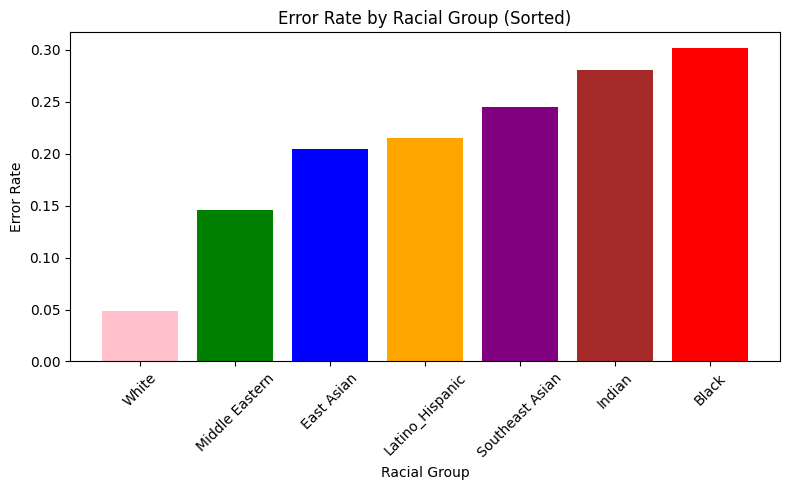

In [15]:
# Plot histogram of error rates for each racial group, sorted by error rate
error_by_race_sorted = error_by_race.sort_values()
plt.figure(figsize=(8, 5))
colors = ['pink', 'green', 'blue', 'orange', 'purple', 'brown', 'red']
plt.bar(error_by_race_sorted.index, error_by_race_sorted.values, color=colors)
plt.xlabel('Racial Group')
plt.ylabel('Error Rate')
plt.title('Error Rate by Racial Group (Sorted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### What do you notice about these findings?

A clear pattern emerges: the model performs significantly better on some racial groups than others. In particular, it achieves its lowest error rate on images of White subjects (under 5%), while its error rate on Black subjects is substantially higher (around 30%). This gap represents a striking disparity in performance across groups.

We can reprsent this disparity mathematically, too, using something called Maximum Accuracy Gap as a sort of proxy measure of how biased the model is. We'll calculate this by just subtracting the lowest accuracy from the highest (in this case, `acc_gap_max = acc_white - acc_black`).


In [16]:
# Error rates by group
error_rates = {
    "Black": 0.3018,
    "East Asian": 0.2046,
    "Indian": 0.2804,
    "Latino_Hispanic": 0.2150,
    "Middle Eastern": 0.1457,
    "Southeast Asian": 0.2447,
    "White": 0.0481
}

# Convert to accuracies
accuracies = {group: 1 - err for group, err in error_rates.items()}

# Compute max accuracy gap
max_acc = max(accuracies.values())
min_acc = min(accuracies.values())
max_gap = max_acc - min_acc

print("Accuracies:", accuracies)
print("Maximum accuracy gap:", max_gap)

Accuracies: {'Black': 0.6981999999999999, 'East Asian': 0.7954, 'Indian': 0.7196, 'Latino_Hispanic': 0.785, 'Middle Eastern': 0.8543000000000001, 'Southeast Asian': 0.7553, 'White': 0.9519}
Maximum accuracy gap: 0.25370000000000004



### What does this suggest about the training data?

Such uneven performance often points to imbalances in the training dataset. The model may have been trained on a disproportionately large number of images of certain groups (especially White subjects) while having less representation from others. As a result, it has learned features that generalize well for some populations but not for others.

### How could the training data be improved?

To reduce these disparities, the training dataset should be made more balanced and representative. This could involve increasing the number and diversity of images from underrepresented groups, ensuring a wider range of lighting conditions, facial features, and contexts. By exposing the model to more varied examples, we can help it learn patterns that generalize more equitably across all groups.

We can also group by other attributes, like sex. Does the model have an easier time identifying male or female subjects? We can find out!

Error for Female: 0.2044
Error for Male: 0.1953


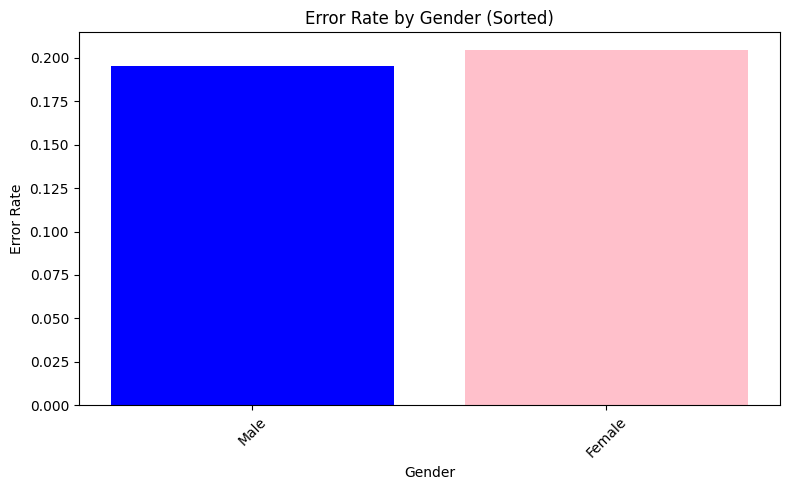

In [17]:
# Group by gender and calculate error for each group
grouped_gender = df.groupby('gender')['correct']
error_by_gender = grouped_gender.apply(lambda x: (len(x) - x.sum()) / len(x))

# Print the percent error for each gender category
for gender, error in error_by_gender.items():
    print(f"Error for {gender}: {error:.4f}")

# Plot histogram of error rates for each gender group, sorted by error rate
error_by_gender_sorted = error_by_gender.sort_values()
plt.figure(figsize=(8, 5))
colors = ['blue', 'pink']  # Adjust colors as needed for genders
plt.bar(error_by_gender_sorted.index, error_by_gender_sorted.values, color=colors)
plt.xlabel('Gender')
plt.ylabel('Error Rate')
plt.title('Error Rate by Gender (Sorted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As we can see, there is much less of a disparity between sexes in the model's evaluations with only an error rate gap of 0.91 percentage points. Therefore, we should be much less concerned with any gender bias in the training data than we should be for race.

Now that you've learned how to evaluate a facial recognition model's biases, we can move on to learning to train our own model, see bias arise for ourselves, and correct it with better training.

## Part 5: Introduction to Machine Learning and Logistic Regression

So far, we have focused on analyzing the outputs of a facial recognition system by measuring accuracy and error across different groups. But where do these predictions come from?

### What is machine learning?

Many AI systems use something called **machine learning**. Instead of following a fixed set of rules, a machine learning model learns patterns from data.

For example, if we show a model many examples of inputs and their correct answers, it can start to learn how to make predictions on new data. This process is often called **supervised learning**, where the model learns from labeled examples (data where we already know the correct answer).

In this tutorial, the model takes in numerical features derived from facial images and tries to predict a label based on those features.

### What is logistic regression?

One simple method we can use is **logistic regression**. Even though it has "regression" in its name, it is commonly used for classification tasks.

Logistic regression works by looking at the input features and combining them using learned weights. It then converts this result into a number between 0 and 1, which we can think of as a probability.

For example, the model might output something like 0.8, meaning it is 80% confident in a certain prediction. Based on this value, the model decides which class the input belongs to.

### What does our logistic regression model code do?

In this tutorial, we use logistic regression as our machine learning model to make predictions based on facial image features.

The model follows a simple pipeline:

1. Load data from a CSV file  
2. Select input features  
3. Select the target labels  
4. Convert labels into numbers  
5. Train a logistic regression model  

First, let’s import the libraries we need.

- pandas: used to read and organize data  
- LogisticRegression: the machine learning model  
- LabelEncoder: converts text labels into numbers  

In [18]:
import os
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

Next, we specify the dataset and which columns we want to use.

The model needs:

- feature columns: numerical inputs used by the model  
- target column: the label the model is trying to predict  

We have prepared three **embeddings** of training datasets, `train_A_emb.csv`, `train_b_emb.csv`, and `train_C_emb.csv`. An **embedding** is a numerical representation of real training images, produced by a pretrained facial recognition model. Instead of raw pixels, each face is encoded as a vector of features that capture things like shape, texture, and structure, so images that look similar end up with similar vectors, making them easier to analyze and compare. 

These embeddings were prepared from real facial recognition training images. Each line in these three files corresponds to an image, with 128 feature vectors and a `file`, `age`, `gender`, and `race` label. (NOTE: Ask Ethan what the `service_test` attr means)

In [19]:
dataset_path = "datasets/"

datasets = {
    "A": "train_A_emb.csv",
    "B": "train_B_emb.csv",
    "C": "train_C_emb.csv"
}

Now, we load the dataset and separate it into inputs and labels.

In [20]:
def load_data(path):
    df = pd.read_csv(path)

    # Features (embeddings)
    feature_cols = df.columns[:128]
    X = df[feature_cols].values

    # Target (what we predict)
    y = df["race"].values

    # Extra attribute (for bias analysis later)
    gender = df["gender"].values

    return X, y, gender, df

Machine learning models require numerical inputs, so we convert labels like "Male" and "Female" into numbers.

In [21]:
def encode_labels(labels):
    # Convert labels like male/female into numbers (0,1)
    le = LabelEncoder()
    encoded = le.fit_transform(labels)
    return le, encoded

Next, we create and train the logistic regression model.
During training, the model learns patterns from the data by adjusting its weights.

In [22]:
def train(input_data, target_encoded):
    # Create the logistic regression model
    model = LogisticRegression(max_iter=1000, random_state=42)
    
    # Train the model
    model.fit(input_data, target_encoded)
    
    return model

Now, we create the model for evaluation of our trained model. Phrase this in your cool tutorial way lol

In [23]:
def evaluate_model(model, X_test, y_test, df_test):
    y_pred = model.predict(X_test)

    # Overall accuracy
    overall_acc = accuracy_score(y_test, y_pred)

    # Add predictions to dataframe
    df_test = df_test.copy()
    df_test["pred"] = y_pred

    # Accuracy by race
    race_acc = (df_test["pred"] == df_test["race"]) \
        .groupby(df_test["race"]) \
        .mean()

    # Accuracy by gender
    gender_acc = (df_test["pred"] == df_test["race"]) \
        .groupby(df_test["gender"]) \
        .mean()

    return overall_acc, race_acc, gender_acc, y_pred

Finally, we put everything together.

This loads the data, converts the labels, and trains the model.

In [24]:
# Load test set once
X_test, y_test, gender_test, test_df = load_data(dataset_path + "test_emb.csv")

models = {}
label_encoders = {}
preds = {}

for name, file in datasets.items():
    # Load training data
    X_train, y_train, _, _ = load_data(dataset_path + file)

    # Encode labels
    le, y_train_enc = encode_labels(y_train)

    # Train model
    model = train(X_train, y_train_enc)

    # Store
    models[name] = model
    label_encoders[name] = le

    # Predict (decode back to labels)
    y_pred_enc = model.predict(X_test)
    y_pred = le.inverse_transform(y_pred_enc)

    preds[name] = y_pred

In [25]:
for name in datasets.keys():
    print(f"\n--- Model {name} ---")

    temp_df = test_df.copy()
    temp_df["pred"] = preds[name]

    # Overall
    overall_acc = accuracy_score(y_test, preds[name])
    print("Overall Accuracy:", overall_acc)

    # By race
    race_acc = (temp_df["pred"] == temp_df["race"]) \
        .groupby(temp_df["race"]) \
        .mean()
    print("\nAccuracy by Race:")
    print(race_acc)

    # By gender
    gender_acc = (temp_df["pred"] == temp_df["race"]) \
        .groupby(temp_df["gender"]) \
        .mean()
    print("\nAccuracy by Gender:")
    print(gender_acc)


--- Model A ---
Overall Accuracy: 0.4107142857142857

Accuracy by Race:
race
Black              0.625
East Asian         0.575
Indian             0.350
Latino_Hispanic    0.225
Middle Eastern     0.300
Southeast Asian    0.400
White              0.400
dtype: float64

Accuracy by Gender:
gender
Female    0.433824
Male      0.388889
dtype: float64

--- Model B ---
Overall Accuracy: 0.3964285714285714

Accuracy by Race:
race
Black              0.500
East Asian         0.550
Indian             0.350
Latino_Hispanic    0.125
Middle Eastern     0.175
Southeast Asian    0.275
White              0.800
dtype: float64

Accuracy by Gender:
gender
Female    0.404412
Male      0.388889
dtype: float64

--- Model C ---
Overall Accuracy: 0.31785714285714284

Accuracy by Race:
race
Black              0.350
East Asian         0.400
Indian             0.300
Latino_Hispanic    0.050
Middle Eastern     0.075
Southeast Asian    0.225
White              0.825
dtype: float64

Accuracy by Gender:
gender
Femal

Or even better, we can graph this data for our viewing pleasure!


--- Model A ---
Overall Accuracy: 0.4107142857142857

--- Model B ---
Overall Accuracy: 0.3964285714285714

--- Model C ---
Overall Accuracy: 0.31785714285714284


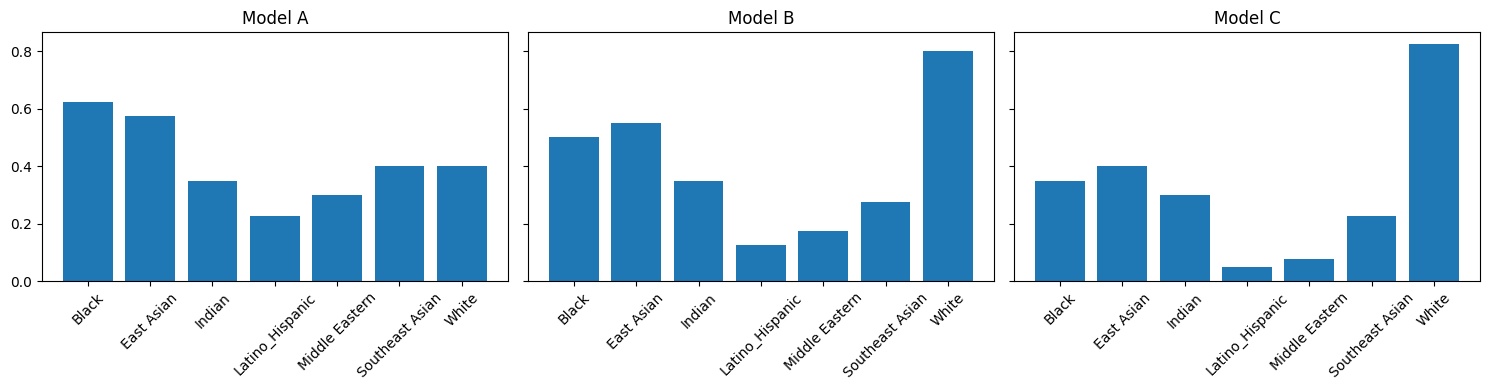

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, name in enumerate(datasets.keys()):
    print(f"\n--- Model {name} ---")

    temp_df = test_df.copy()
    temp_df["pred"] = preds[name]

    # Overall
    overall_acc = accuracy_score(y_test, preds[name])
    print("Overall Accuracy:", overall_acc)

    # By race
    race_acc = (temp_df["pred"] == temp_df["race"]) \
        .groupby(temp_df["race"]) \
        .mean()

    # Plot
    axes[i].bar(race_acc.index, race_acc.values)
    axes[i].set_title(f"Model {name}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

And then for gender, too...

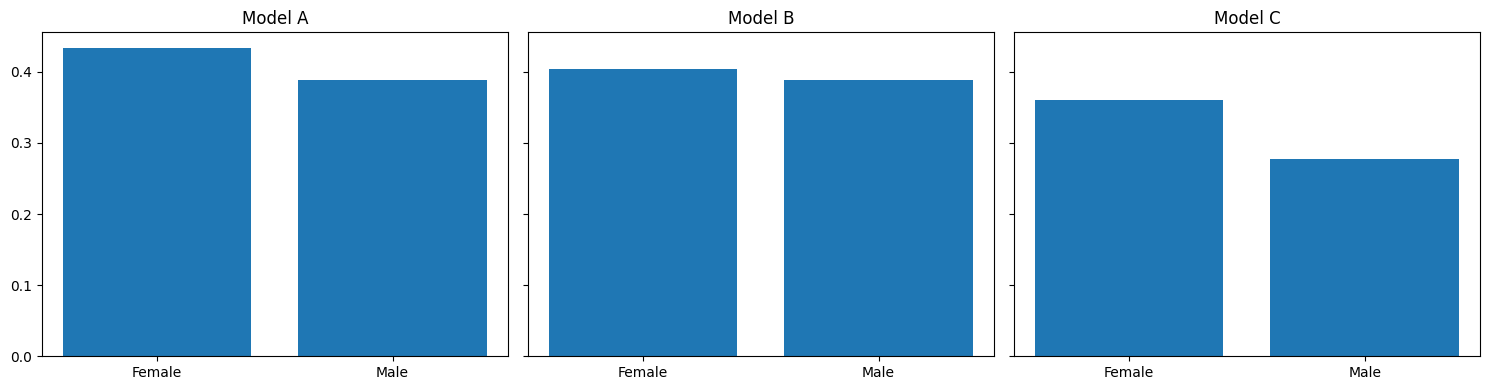

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, name in enumerate(datasets.keys()):
    temp_df = test_df.copy()
    temp_df["pred"] = preds[name]

    gender_acc = (temp_df["pred"] == temp_df["race"]) \
        .groupby(temp_df["gender"]) \
        .mean()

    axes[i].bar(gender_acc.index, gender_acc.values)
    axes[i].set_title(f"Model {name}")
    axes[i].tick_params(axis='x')

plt.tight_layout()
plt.show()

## Part 6: Change the Data, Change the Bias

Now that we've got a handle on our bias analysis, let's have a look at how the underlying demographic differences in our three datasets influenced their biases. 

Let's take a look at the racial makeup of the `train_A_emb.csv`, `train_b_emb.csv`, and `train_C_emb.csv` datasets:

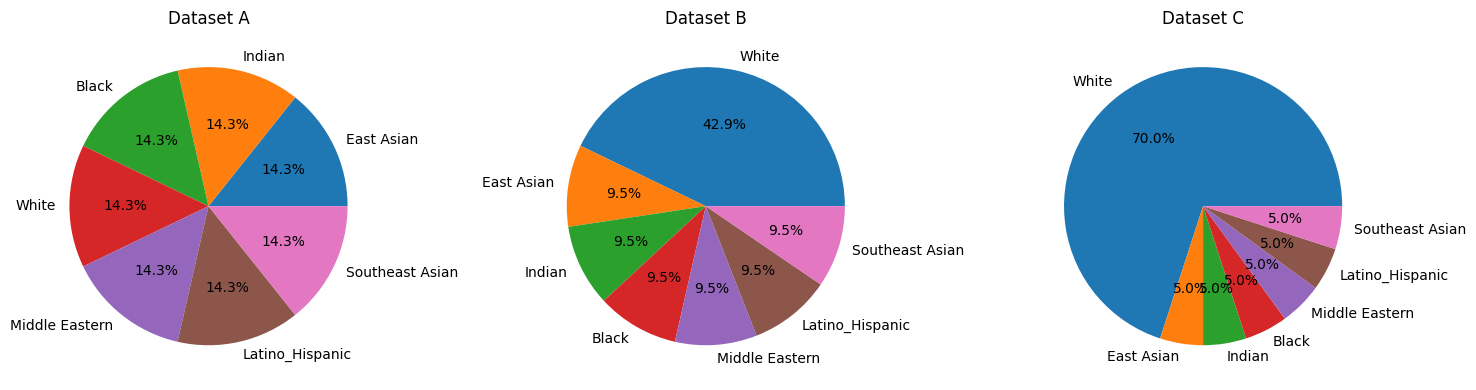

In [ ]:
# Make Pie Charts of racial distribution in each dataset!

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, name in enumerate(datasets.keys()):
    df = pd.read_csv(dataset_path + datasets[name])

    race_dist = df["race"].value_counts(normalize=True)

    axes[i].pie(
        race_dist.values,
        labels=race_dist.index,
        autopct='%1.1f%%'
    )
    axes[i].set_title(f"Dataset {name}")

plt.tight_layout()
plt.show()